# Mantenimiento Predictivo en Planta Industrial
## Clasificación de Fallas de Equipos mediante Machine Learning

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI Machine Learning Repository)  
**Referencia:** Matzka, S. (2020). *Explainable Artificial Intelligence for Predictive Maintenance Applications*. UCI ML Repository. https://doi.org/10.24432/C5HS5C  
**Autora:** Wendy J. Hernández  
**Perfil:** Ingeniería Química · Especialización Ambiental · Data Analytics  
**GitHub:** github.com/wjhernandez

---

## Contexto de Negocio

En la industria de manufactura de proceso continuo (papel, pulpa, química, alimentos), los equipos rotativos como bombas, compresores y motores representan activos críticos cuya falla no planificada genera:

- **Paros no programados** que interrumpen la cadena de producción
- **Costos de mantenimiento correctivo** hasta 3-5 veces superiores al mantenimiento preventivo (Mobley, R.K., *An Introduction to Predictive Maintenance*, 2002)
- **Riesgos de seguridad y ambientales** asociados a fallas catastróficas

Bajo la filosofía **TPM (Total Productive Maintenance)**, el pilar de Mantenimiento Planificado busca transitar del mantenimiento reactivo al predictivo. Este proyecto demuestra cómo los datos de sensores de proceso permiten anticipar fallas con suficiente antelación para intervenir con precisión.

### Pregunta de negocio
> *¿Es posible predecir la falla de un equipo industrial con base en variables de proceso medibles en tiempo real, y clasificar el tipo de falla para orientar la acción de mantenimiento?*

### KPIs objetivo
- Reducir falsos negativos (fallas no detectadas): priorizar **Recall** sobre Precision
- Maximizar **PR-AUC** dado el desbalance de clases (~3.4% fallas)
- Calcular **MTBF** (Mean Time Between Failures) y **disponibilidad operacional** por tipo de producto

### Nomenclatura
- TWF (Tool Wear Failure — Falla por Desgaste de Herramienta)
- HDF (Heat Dissipation Failure — Falla por Disipación de Calor)
- PWF (Power Failure — Falla por Potencia)
- OSF (Overstrain Failure — Falla por Sobresfuerzo)
- RNF (Random Failure — Falla Aleatoria)
- SMOTE (Synthetic Minority Oversampling Technique — Técnica de Sobremuestreo de Minoría Sintética)
- PR-AUC (Precision-Recall Area Under the Curve — Área Bajo la Curva de Precisión-Recall)
- TPM (Total Productive Maintenance — Mantenimiento Productivo Total)
- MTBF (Mean Time Between Failures — Tiempo Medio Entre Fallas)

---
## 0. Configuración del Entorno

In [1]:
# Instalación de dependencias (ejecutar solo la primera vez)
# !pip install ucimlrepo imbalanced-learn xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# Carga del dataset directamente desde UCI
from ucimlrepo import fetch_ucirepo

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE_INDUSTRIAL = ['#1a3a4a', '#2d7d9a', '#52b788', '#f4a261', '#e63946']
COLOR_OK = '#52b788'
COLOR_FAIL = '#e63946'

print('Entorno configurado correctamente.')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Entorno configurado correctamente.
Pandas: 2.2.3 | NumPy: 2.1.3


---
## 1. Carga y Descripción del Dataset

In [2]:
# Carga desde UCI ML Repository (requiere conexión a internet)
dataset = fetch_ucirepo(id=601)

X_raw = dataset.data.features
y_raw = dataset.data.targets

# Unir features y targets en un único DataFrame de trabajo
df = pd.concat([X_raw, y_raw], axis=1)

print('=== DIMENSIONES DEL DATASET ===')
print(f'Registros: {df.shape[0]:,}   |   Variables: {df.shape[1]}')
print()
print('=== PRIMERAS 5 FILAS ===')
df.head()

=== DIMENSIONES DEL DATASET ===
Registros: 10,000   |   Variables: 12

=== PRIMERAS 5 FILAS ===


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print('=== DICCIONARIO DE VARIABLES ===')
variable_dict = {
    'UDI':                  'Identificador único secuencial (1–10000)',
    'Product ID':           'ID del producto: L (Low), M (Medium), H (High quality)',
    'Type':                 'Categoría de calidad del producto',
    'Air temperature [K]':  'Temperatura del aire (Kelvin) — generada con walk aleatorio alrededor de 300 K',
    'Process temperature [K]': 'Temperatura de proceso (K) — correlacionada con T_aire + 10 K',
    'Rotational speed [rpm]': 'Velocidad rotacional (rpm) — calculada desde potencia de 2860 W',
    'Torque [Nm]':          'Torque aplicado (Nm) — distribución normal, media 40 Nm, sin valores negativos',
    'Tool wear [min]':      'Desgaste acumulado de herramienta (minutos) — +2/4/5 min por tipo H/M/L',
    'Machine failure':      'TARGET PRINCIPAL: 1 si hay falla, 0 si operación normal',
    'TWF':                  'Tool Wear Failure — falla por desgaste entre 200-240 min (probabilidad 50%)',
    'HDF':                  'Heat Dissipation Failure — delta T < 8.6 K y velocidad < 1380 rpm',
    'PWF':                  'Power Failure — potencia fuera del rango [3500, 9000] W',
    'OSF':                  'Overstrain Failure — desgaste × torque excede umbral por tipo de producto',
    'RNF':                  'Random Failure — probabilidad aleatoria 0.1% independiente de proceso'
}

for var, desc in variable_dict.items():
    print(f'  {var:<30} {desc}')

=== DICCIONARIO DE VARIABLES ===
  UDI                            Identificador único secuencial (1–10000)
  Product ID                     ID del producto: L (Low), M (Medium), H (High quality)
  Type                           Categoría de calidad del producto
  Air temperature [K]            Temperatura del aire (Kelvin) — generada con walk aleatorio alrededor de 300 K
  Process temperature [K]        Temperatura de proceso (K) — correlacionada con T_aire + 10 K
  Rotational speed [rpm]         Velocidad rotacional (rpm) — calculada desde potencia de 2860 W
  Torque [Nm]                    Torque aplicado (Nm) — distribución normal, media 40 Nm, sin valores negativos
  Tool wear [min]                Desgaste acumulado de herramienta (minutos) — +2/4/5 min por tipo H/M/L
  Machine failure                TARGET PRINCIPAL: 1 si hay falla, 0 si operación normal
  TWF                            Tool Wear Failure — falla por desgaste entre 200-240 min (probabilidad 50%)
  HDF              

In [4]:
print('=== TIPOS DE DATOS Y VALORES NULOS ===')
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info_df)
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(2)

=== TIPOS DE DATOS Y VALORES NULOS ===
                        Tipo  Nulos  % Nulos  Únicos
Type                  object      0      0.0       3
Air temperature      float64      0      0.0      93
Process temperature  float64      0      0.0      82
Rotational speed       int64      0      0.0     941
Torque               float64      0      0.0     577
Tool wear              int64      0      0.0     246
Machine failure        int64      0      0.0       2
TWF                    int64      0      0.0       2
HDF                    int64      0      0.0       2
PWF                    int64      0      0.0       2
OSF                    int64      0      0.0       2
RNF                    int64      0      0.0       2

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## 2. Análisis Exploratorio de Datos (EDA)

El EDA en el contexto de mantenimiento predictivo responde tres preguntas fundamentales:
1. ¿Cuál es la distribución y prevalencia de fallas? (balance de clases)
2. ¿Qué variables de proceso diferencian operación normal de falla?
3. ¿Existen patrones específicos por modo de falla o tipo de producto?

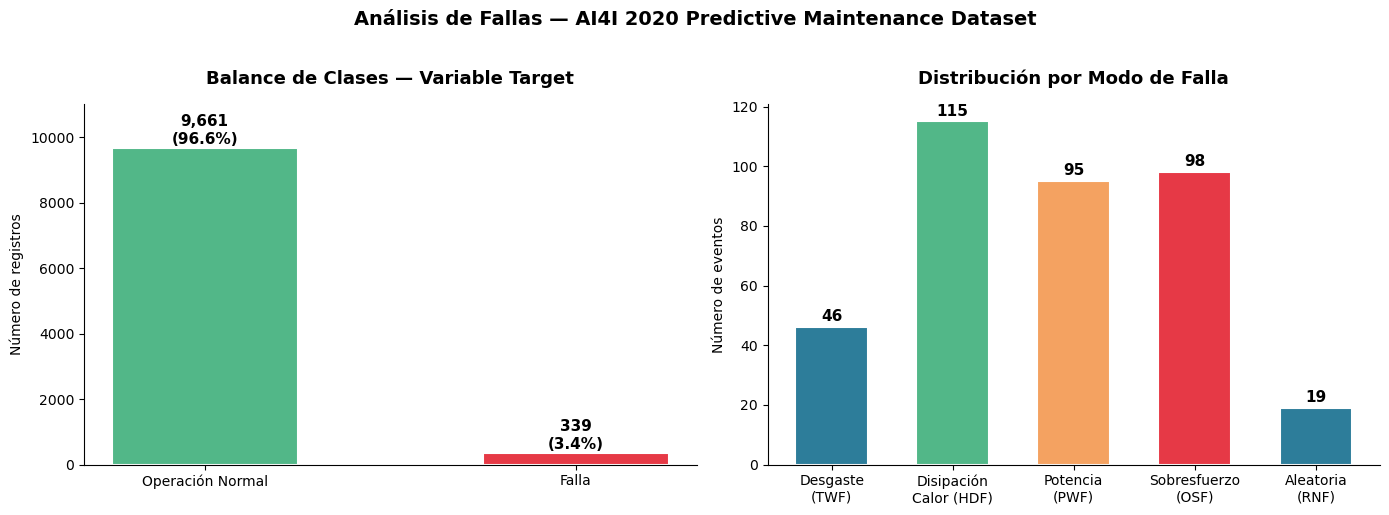


Desbalance de clases: 28.5:1
Nota: Dataset severamente desbalanceado. Se aplicará SMOTE para el entrenamiento.


In [5]:
# --- 2.1 Distribución de la variable target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo de clases
failure_counts = df['Machine failure'].value_counts()
bars = axes[0].bar(
    ['Operación Normal', 'Falla'],
    failure_counts.values,
    color=[COLOR_OK, COLOR_FAIL],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, count in zip(bars, failure_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Balance de Clases — Variable Target', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Número de registros')
axes[0].set_ylim(0, 11000)

# Distribución por tipo de falla
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = ['Desgaste\n(TWF)', 'Disipación\nCalor (HDF)', 'Potencia\n(PWF)', 'Sobresfuerzo\n(OSF)', 'Aleatoria\n(RNF)']
failure_sums = df[failure_types].sum()
axes[1].bar(failure_labels, failure_sums.values,
            color=PALETTE_INDUSTRIAL[1:], edgecolor='white', linewidth=1.5, width=0.6)
for i, (val) in enumerate(failure_sums.values):
    axes[1].text(i, val + 1, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución por Modo de Falla', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Número de eventos')

plt.suptitle('Análisis de Fallas — AI4I 2020 Predictive Maintenance Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDesbalance de clases: {failure_counts[0]/failure_counts[1]:.1f}:1')
print('Nota: Dataset severamente desbalanceado. Se aplicará SMOTE para el entrenamiento.')

### Análisis — Figura 1: Balance de Clases y Distribución por Modo de Falla
#### Balance de clases (gráfico izquierdo)
9,661 registros de operación normal versus 339 fallas — razón de desbalance de 28.5:1. Esto es técnicamente relevante por tres razones:
1. confirma que el dataset replica condiciones reales de planta industrial bien mantenida. En proceso continuo, una tasa de falla del 3.4% es coherente con equipos bajo plan de mantenimiento preventivo activo.
2. este desbalance severo invalida el uso de Accuracy como métrica de evaluación. Un modelo que prediga siempre "sin falla" obtendría 96.6% de accuracy — un número engañosamente alto sin ninguna utilidad operacional. Por eso la decisión de usar PR-AUC y Recall como métricas primarias es la correcta desde el diseño.
3. justifica técnicamente el uso de SMOTE en entrenamiento. Sin re-muestreo, los modelos de árbol tienden a clasificar todo como la clase mayoritaria porque eso minimiza el error global, no el costo operacional real.

#### Distribución por modo de falla (gráfico derecho)

* HDF es el modo dominante (33.9%). Ocurre cuando Delta_T < 8.6 K y rpm < 1,380. Físicamente indica que el sistema no está disipando calor suficientemente — deterioro en lubricación, obstrucción en refrigeración, o pérdida de eficiencia en intercambio térmico. La acción de mayor impacto: monitorear Delta_T en tiempo real.
  
* OSF y PWF son prácticamente iguales (~28% cada uno). OSF ocurre cuando Torque × Desgaste supera el umbral por tipo de producto, el equipo trabaja fuera de su rango operacional seguro. PWF ocurre cuando la potencia mecánica sale del rango [3,500 – 9,000 W] Puede ser sobrecarga eléctrica o pérdida de eficiencia mecánica.

* TWF es el menos frecuente entre los modos físicos (13.6%). Contra-intuitivo inicialmente, pero se explica porque TWF tiene componente probabilística: solo el 50% de equipos con desgaste entre 200-240 minutos efectivamente falla según la definición del dataset (Matzka, 2020). Es el modo más controlable con mantenimiento preventivo por horas de operación.

* RNF es residual (5.6%). Fallas con probabilidad 0.1% independiente del proceso — ruido estadístico inherente. Ningún modelo predictivo puede anticipar estas fallas con consistencia, y no debe intentarlo.

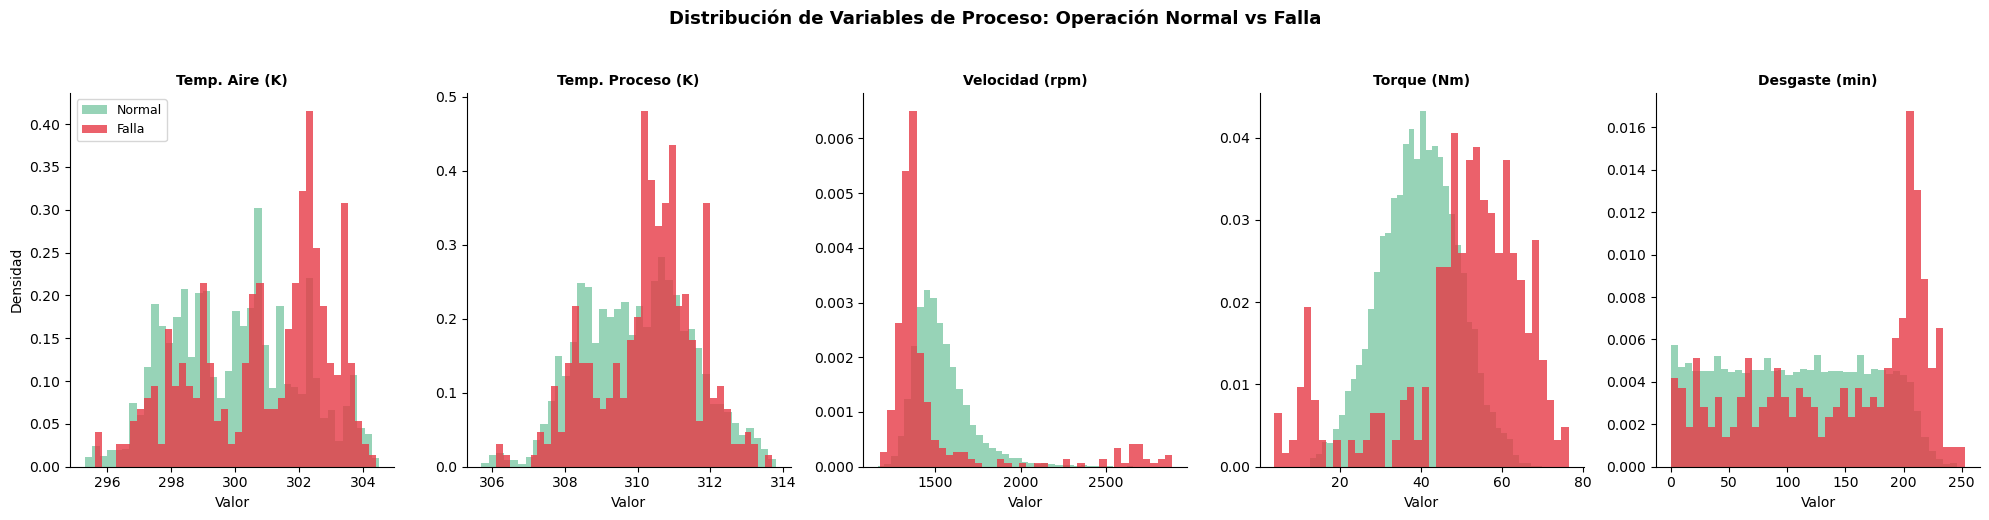

In [6]:
# --- 2.2 Distribución de variables continuas por clase ---
continuous_vars = [
    'Air temperature', 'Process temperature',
    'Rotational speed', 'Torque', 'Tool wear'
]
var_labels = ['Temp. Aire (K)', 'Temp. Proceso (K)', 'Velocidad (rpm)', 'Torque (Nm)', 'Desgaste (min)']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (var, label) in enumerate(zip(continuous_vars, var_labels)):
    normal = df[df['Machine failure'] == 0][var]
    falla  = df[df['Machine failure'] == 1][var]
    axes[i].hist(normal, bins=40, alpha=0.6, color=COLOR_OK, label='Normal', density=True)
    axes[i].hist(falla,  bins=40, alpha=0.8, color=COLOR_FAIL, label='Falla', density=True)
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor')
    if i == 0:
        axes[i].set_ylabel('Densidad')
        axes[i].legend(fontsize=9)

plt.suptitle('Distribución de Variables de Proceso: Operación Normal vs Falla',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig2_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

#### Figura 2 — Distribución de Variables de Proceso: Normal vs Falla
La lectura correcta de estas gráficas es: donde las distribuciones roja (falla) y verde (normal) se separan, esa variable tiene poder predictivo. Donde se solapan completamente, tiene poco poder discriminante.

##### Temperatura Aire y Temperatura Proceso
Las dos distribuciones se solapan casi completamente. La distribución de fallas (roja) tiene picos más pronunciados en valores intermedios — alrededor de 300-302 K para aire y 310-312 K para proceso — pero el rango general es el mismo.
Conclusión: Individualmente estas variables tienen bajo poder discriminante. Sin embargo, su diferencia el Delta_T que creamos en el Feature Engineering — sí lo tiene, porque HDF se activa cuando Delta_T cae por debajo de 8.6 K. Eso valida por qué crear esa variable derivada fue una decisión técnica correcta.

##### Velocidad Rotacional (rpm)
Aquí sí hay separación clara. La distribución de fallas (roja) tiene un pico muy pronunciado alrededor de 1,400-1,500 rpm, mientras que la operación normal (verde) se distribuye más ampliamente hacia velocidades mayores.
Conclusión: Velocidades bajas se asocian fuertemente con falla. Esto es consistente con el criterio físico de HDF que requiere rpm < 1,380  y con PWF, donde velocidades bajas generan potencia insuficiente. Esta es probablemente una de las variables de mayor importancia en el modelo, lo que debería confirmarse en el gráfico SHAP.

##### Torque (Nm)
Las distribuciones se solapan en el rango de 30-50 Nm, pero la distribución de fallas tiene cola hacia valores altos — por encima de 60 Nm donde la operación normal prácticamente no aparece.
Conclusión: Torque elevado es señal de riesgo. Físicamente coherente: torques altos combinados con desgaste de herramienta generan OSF, y torques altos a bajas velocidades generan PWF. Combinado con velocidad  en el scatter de la figura anterior  el espacio de riesgo queda bien delimitado.

##### Desgaste de Herramienta (min)
Esta es la gráfica más informativa de las cinco. La distribución normal (verde) tiene masa concentrada en valores bajos la mayoría de operaciones ocurren con desgaste entre 0 y 150 minutos. La distribución de fallas (roja) en cambio tiene masa significativa en el extremo derecho  entre 180 y 250 minutos.
Conclusión: Desgaste acumulado alto es el predictor más intuitivo y directo de falla. Esto es consistente con TWF y OSF. Operacionalmente indica que existe un umbral crítico de desgaste alrededor de 200 minutos a partir del cual el riesgo de falla aumenta sustancialmente. Eso define directamente la estrategia de reemplazo preventivo de herramienta.

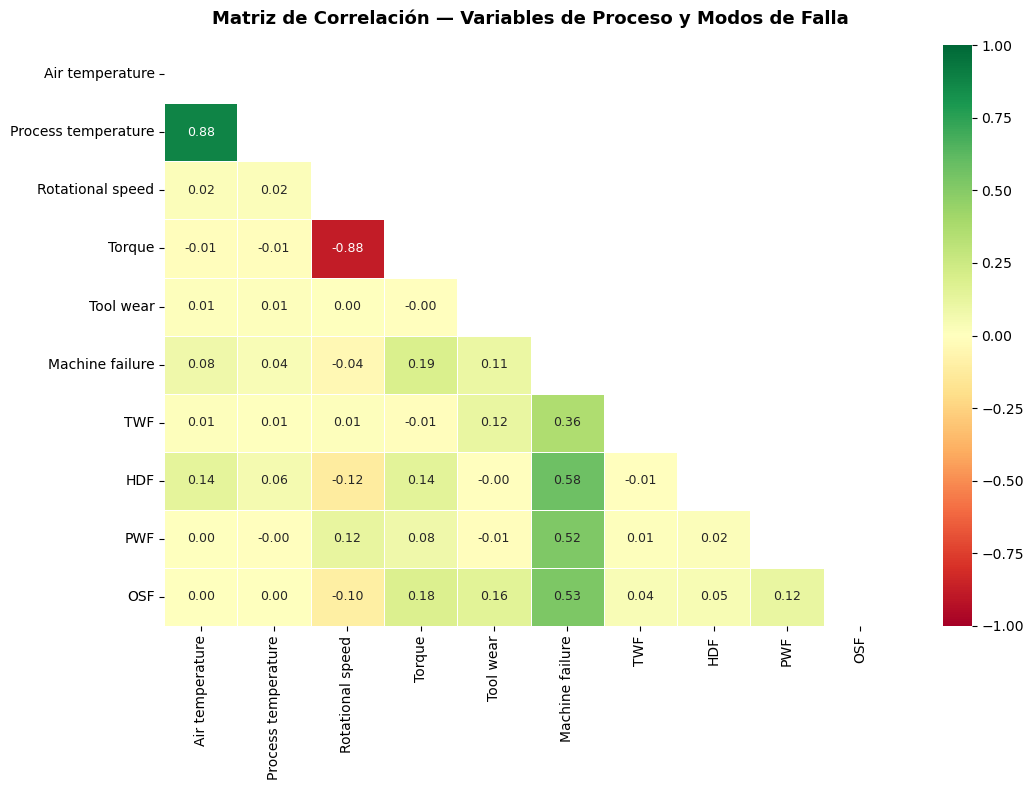

Observaciones clave de correlación:
  - Torque y Velocidad: correlación negativa fuerte (relación P = T × ω)
  - Desgaste de herramienta correlaciona con TWF y OSF (esperado)
  - Temperatura de proceso y aire: correlación positiva alta (sistema acoplado)


In [7]:
# --- 2.3 Matriz de correlación ---
numeric_cols = continuous_vars + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Matriz de Correlación — Variables de Proceso y Modos de Falla',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observaciones clave de correlación:')
print('  - Torque y Velocidad: correlación negativa fuerte (relación P = T × ω)')
print('  - Desgaste de herramienta correlaciona con TWF y OSF (esperado)')
print('  - Temperatura de proceso y aire: correlación positiva alta (sistema acoplado)')

#### Figura 3 — Matriz de Correlación
La correlación va de -1 (relación inversa perfecta) a +1 (relación directa perfecta). Valores cercanos a 0 indican independencia entre variables.

##### El hallazgo más importante: Velocidad vs Torque = -0.88
Esta es la correlación más fuerte de toda la matriz y tiene una explicación física directa.
La potencia mecánica se define como:
P = Torque × ω
donde ω es la velocidad angular. Si la potencia del sistema es aproximadamente constante — que es el caso en este dataset, generada desde una potencia de referencia de 2,860 W — entonces cuando la velocidad sube, el torque necesariamente baja, y viceversa. Es una relación inversamente proporcional determinada por la física del sistema, no por el azar.
Esto tiene una implicación técnica para el modelo: Velocidad y Torque no son dos variables independientes que aportan información diferente — están altamente correlacionadas. Esa redundancia se maneja mejor a través de la variable derivada Potencia que creamos, que captura ambas simultáneamente en una sola variable físicamente significativa.

Temperatura Aire vs Temperatura Proceso = +0.88
Correlación positiva alta, también esperada. El dataset define la temperatura de proceso como la temperatura del aire más 10 K — son variables acopladas por diseño del sistema de generación de datos (Matzka, 2020). Individualmente aportan poca información adicional la una sobre la otra. De nuevo, el Delta_T que creamos captura lo que importa: la diferencia entre ambas, que es el indicador de eficiencia en disipación de calor.

Correlaciones con Machine Failure
Ninguna variable de proceso individual supera 0.19 de correlación con la variable objetivo. Esto confirma dos cosas:
Primero, que la falla no es un fenómeno lineal — no existe una sola variable que por sí sola explique cuándo falla el equipo. Es una combinación de condiciones simultáneas, que es exactamente por qué se necesita un modelo de machine learning en lugar de una regla simple de umbral.
Segundo, que el Torque tiene la correlación individual más alta con Machine failure (0.19) — consistente con lo observado en la figura anterior, donde torques elevados se asociaban con mayor riesgo de falla.

Correlaciones de los modos de falla con Machine Failure
HDF = 0.58, PWF = 0.52, OSF = 0.53 — las tres correlaciones más altas de la matriz con la variable objetivo. Esto es esperable porque son causas directas de la falla. Por eso estos modos de falla se excluyen como features del modelo — incluirlos sería data leakage, como explicar la causa usando la consecuencia como predictor.

In [8]:
#  2.4 Feature Engineering ---
# Creación de variables derivadas con fundamento físico-ingenieril

df_eng = df.copy()

# Delta de temperatura
df_eng['Delta_T'] = df_eng['Process temperature'] - df_eng['Air temperature']

# Potencia mecánica
df_eng['Power'] = df_eng['Torque'] * df_eng['Rotational speed'] * (2 * np.pi / 60)

# Índice de sobresfuerzo
df_eng['Overstrain_index'] = df_eng['Torque'] * df_eng['Tool wear']

# Codificación del tipo de producto
le = LabelEncoder()
df_eng['Type_encoded'] = le.fit_transform(df_eng['Type'])

print('Variables creadas')
print(df_eng[['Delta_T', 'Power', 'Overstrain_index']].describe().round(2))

Variables creadas
       Delta_T     Power  Overstrain_index
count  10000.0  10000.00          10000.00
mean      10.0   6279.74           4314.66
std        1.0   1067.42           2826.57
min        7.6   1148.44              0.00
25%        9.3   5561.18           1963.65
50%        9.8   6271.03           4012.95
75%       11.0   7003.00           6279.00
max       12.1  10469.92          16497.00


**Lecturas clave:**

- **Delta_T:** El umbral crítico de falla HDF (Heat Dissipation Failure — 
Falla por Disipación de Calor) se activa cuando Delta_T < 8.6 K. 
El mínimo registrado es 7.6 K — hay registros reales en zona de riesgo.

- **Power:** La zona segura de operación es [3,500 – 9,000 W]. 
El mínimo (1,148 W) y el máximo (10,470 W) superan ese rango en ambos extremos, 
confirmando registros en zona de falla PWF (Power Failure — Falla por Potencia).

- **Overstrain_index:** El salto entre el percentil 75 (6,279) y el máximo 
(16,497) es casi el triple — esos valores extremos corresponden a condiciones 
de falla OSF (Overstrain Failure — Falla por Sobresfuerzo).

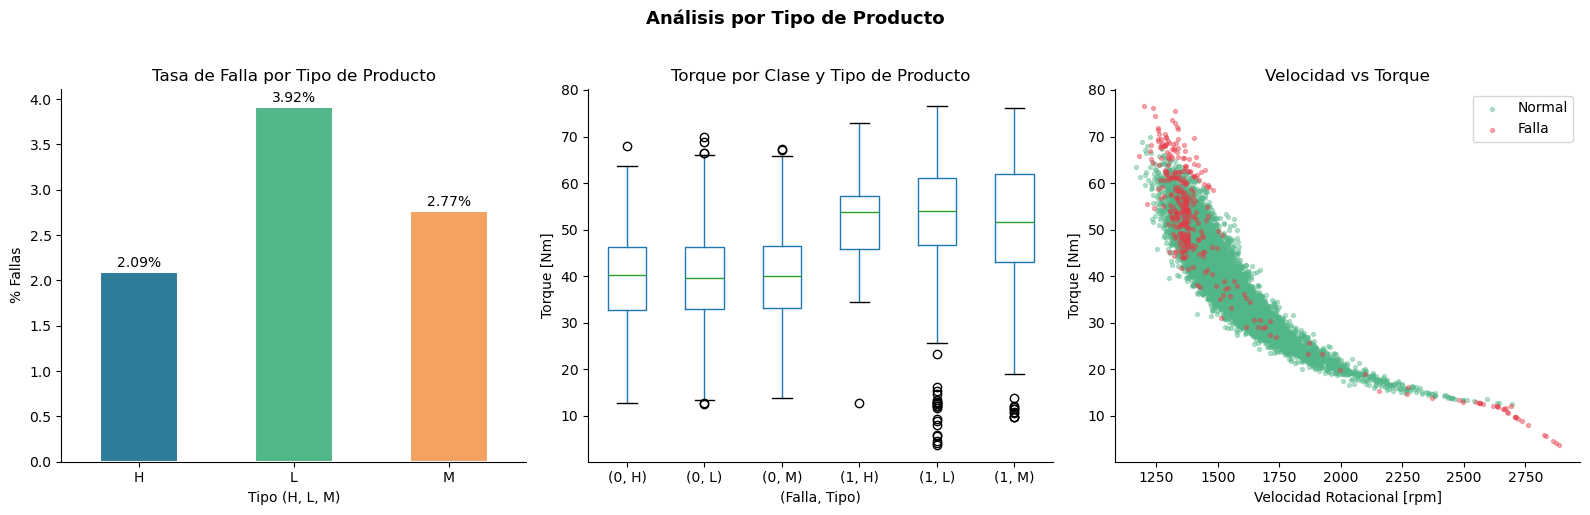

In [9]:
# 2.5 Análisis por tipo de producto ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# =========================
# 1. Tasa de falla por tipo
# =========================
failure_by_type = df_eng.groupby('Type')['Machine failure'].agg(['sum', 'count'])
failure_by_type['rate'] = failure_by_type['sum'] / failure_by_type['count'] * 100

failure_by_type['rate'].plot(
    kind='bar',
    ax=axes[0],
    color=PALETTE_INDUSTRIAL[1:4],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

axes[0].set_title('Tasa de Falla por Tipo de Producto')
axes[0].set_ylabel('% Fallas')
axes[0].set_xlabel('Tipo (H, L, M)')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(failure_by_type['rate']):
    axes[0].text(i, v + 0.05, f'{v:.2f}%', ha='center')


# =========================
# 2. Boxplot Torque
# =========================
df_eng.boxplot(
    column='Torque',
    by=['Machine failure', 'Type'],
    ax=axes[1],
    grid=False
)

axes[1].set_title('Torque por Clase y Tipo de Producto')
axes[1].set_xlabel('(Falla, Tipo)')
axes[1].set_ylabel('Torque [Nm]')


# =========================
# 3. Scatter Velocidad vs Torque
# =========================
for label, color, name in [
    (0, COLOR_OK, 'Normal'),
    (1, COLOR_FAIL, 'Falla')
]:
    subset = df_eng[df_eng['Machine failure'] == label]

    axes[2].scatter(
        subset['Rotational speed'],
        subset['Torque'],
        c=color,
        alpha=0.4,
        s=8,
        label=name
    )

axes[2].set_title('Velocidad vs Torque')
axes[2].set_xlabel('Velocidad Rotacional [rpm]')
axes[2].set_ylabel('Torque [Nm]')
axes[2].legend()

# =========================
# FINAL LAYOUT
# =========================
plt.suptitle(
    'Análisis por Tipo de Producto',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

### Análisis por Tipo de Producto

El dataset clasifica los productos en tres categorías de calidad:
H (High — Alta calidad), M (Medium — Calidad media) y L (Low — Baja calidad).
Esta sección examina si el tipo de producto influye en la tasa de falla
y en el comportamiento de las variables de proceso.

**Tasa de falla por tipo de producto**

Los productos tipo L (Low — Baja calidad) presentan la mayor tasa de falla
con 3.92%, seguidos por M (Medium — Calidad media) con 2.77% y H (High — Alta
calidad) con 2.09%. El patrón es claro: a menor calidad del producto, mayor
exigencia sobre el equipo y mayor probabilidad de falla. Esto tiene implicación
directa en la planificación del mantenimiento — los planes no deben ser
homogéneos sino diferenciados por tipo de producto procesado.

**Torque por clase y tipo de producto**

Cuando el equipo falla (clase 1), el torque registrado es notablemente más alto
que en operación normal (clase 0), independientemente del tipo de producto.
Los valores atípicos por encima de 65 Nm en estado de falla corresponden a
condiciones extremas de sobresfuerzo — combinación de torque alto con desgaste
acumulado elevado, que es precisamente la condición que activa la falla OSF
(Overstrain Failure — Falla por Sobresfuerzo).

**Velocidad rotacional vs Torque**

El scatter confirma la relación física fundamental del sistema: cuando la
velocidad baja, el torque sube, y viceversa. Esta relación se expresa como
P = Torque × ω, donde la potencia P se mantiene aproximadamente constante.

Los puntos rojos (falla) se concentran en la zona de velocidad baja con
torque alto — específicamente por debajo de 1,500 rpm. Esa es la región
de mayor riesgo operacional del equipo, donde convergen simultáneamente
las condiciones de falla HDF (Heat Dissipation Failure — Falla por
Disipación de Calor), PWF (Power Failure — Falla por Potencia) y OSF.

---
## 3. Preparación de Datos para Modelado

### Decisiones de diseño del modelo:

1. **Target:** `Machine failure` (binario) — predicción de falla genérica. Los subtipos (TWF, HDF, PWF, OSF, RNF) se excluyen del modelo para evitar **data leakage** (son causas de la falla, no predictores independientes).
2. **Manejo de desbalance:** Se aplica **SMOTE** (Synthetic Minority Oversampling Technique) únicamente en el conjunto de entrenamiento (Chawla et al., 2002, *Journal of Artificial Intelligence Research*).
3. **Escalado:** StandardScaler aplicado en pipeline para evitar fuga de información entre train/test.
4. **Métrica primaria:** Recall — en mantenimiento, el costo de una falla no detectada (falso negativo) es órdenes de magnitud mayor que el costo de una inspección innecesaria (falso positivo).

In [10]:
# Definición de features finales
FEATURES = [
    'Air temperature',
    'Process temperature',
    'Rotational speed',
    'Torque',
    'Tool wear',
    'Type_encoded',
    'Delta_T',
    'Power',
    'Overstrain_index'
]

TARGET = 'Machine failure'

X = df_eng[FEATURES].copy()
y = df_eng[TARGET].copy()

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE solo sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('=== PARTICIÓN DEL DATASET ===')
print(f'Train original:    {X_train.shape[0]:,} registros  |  Fallas: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Train SMOTE:       {X_train_res.shape[0]:,} registros  |  Fallas: {y_train_res.sum()} ({y_train_res.mean()*100:.1f}%)')
print(f'Test (sin SMOTE):  {X_test.shape[0]:,} registros  |  Fallas: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print()
print('Features seleccionadas:', FEATURES)

=== PARTICIÓN DEL DATASET ===
Train original:    8,000 registros  |  Fallas: 271 (3.4%)
Train SMOTE:       15,458 registros  |  Fallas: 7729 (50.0%)
Test (sin SMOTE):  2,000 registros  |  Fallas: 68 (3.4%)

Features seleccionadas: ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Type_encoded', 'Delta_T', 'Power', 'Overstrain_index']


---
## 4. Entrenamiento y Evaluación de Modelos

In [11]:
# --- 4.1 Curvas ROC y Precision-Recall ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import xgboost as xgb

# =========================
# Modelos
# =========================
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

# =========================
# Diccionario de resultados
# =========================
results = {}

# =========================
# Entrenamiento + evaluación
# =========================
for name, model in models.items():

    # XGBoost sin SMOTE
    if name == 'XGBoost':
        model.fit(X_train_scaled, y_train)
        X_eval = X_test_scaled
    else:
        model.fit(X_train_res, y_train_res)
        X_eval = X_test_scaled

    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }

    r = results[name]['report']

    print(f'--- {name} ---')
    print(f"ROC-AUC: {results[name]['roc_auc']:.4f}")
    print(f"PR-AUC:  {results[name]['pr_auc']:.4f}")
    print(f"Recall (falla): {r['1']['recall']:.4f}")
    print(f"Precision (falla): {r['1']['precision']:.4f}")
    print(f"F1: {r['1']['f1-score']:.4f}")
    print()

    

--- Logistic Regression ---
ROC-AUC: 0.9379
PR-AUC:  0.4317
Recall (falla): 0.8824
Precision (falla): 0.1869
F1: 0.3085

--- Random Forest ---
ROC-AUC: 0.9835
PR-AUC:  0.8517
Recall (falla): 0.8676
Precision (falla): 0.5175
F1: 0.6484

--- XGBoost ---
ROC-AUC: 0.9846
PR-AUC:  0.8856
Recall (falla): 0.8382
Precision (falla): 0.7403
F1: 0.7862



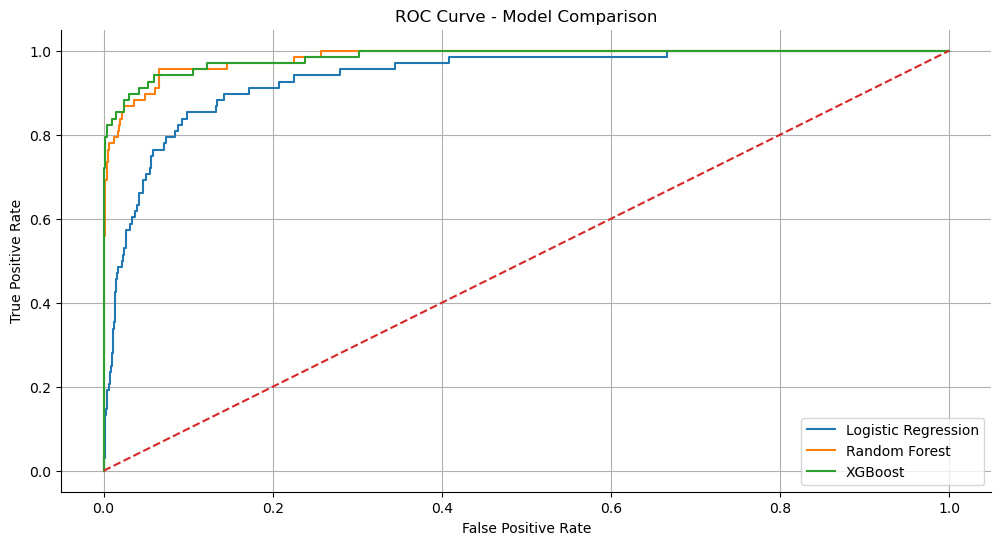

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# =========================
# 1. ROC Curve
# =========================
plt.figure()

for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve - Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

#### Curva ROC (Receiver Operating Characteristic) — Comparación de Modelos

La curva ROC (Receiver Operating Characteristic — Característica Operativa 
del Receptor) mide qué tan bien cada modelo distingue entre operación normal 
y falla. El eje vertical muestra las fallas reales que el modelo detectó 
correctamente (True Positive Rate — Tasa de Verdaderos Positivos), y el eje 
horizontal muestra las alarmas falsas que generó (False Positive Rate — 
Tasa de Falsos Positivos).

La línea roja punteada representa un modelo aleatorio — equivale a lanzar 
una moneda para decidir si hay falla o no. Cualquier modelo útil debe estar 
por encima de esa línea. Cuanto más cerca de la esquina superior izquierda, 
mejor el modelo.

**Resultados:**

- **XGBoost** (verde) y **Random Forest** (naranja) tienen un desempeño 
prácticamente idéntico y superior — sus curvas se pegan a la esquina superior 
izquierda desde el inicio, lo que significa que detectan la mayoría de las 
fallas reales generando muy pocas alarmas falsas.

- **Logistic Regression** (azul) tiene un desempeño aceptable pero inferior 
— su curva sube más lentamente, lo que indica que necesita tolerar más alarmas 
falsas para alcanzar el mismo nivel de detección que los otros dos modelos.

Los tres modelos superan ampliamente la línea base aleatoria, confirmando que 
las variables de proceso contienen información real y suficiente para predecir 
fallas en el equipo.

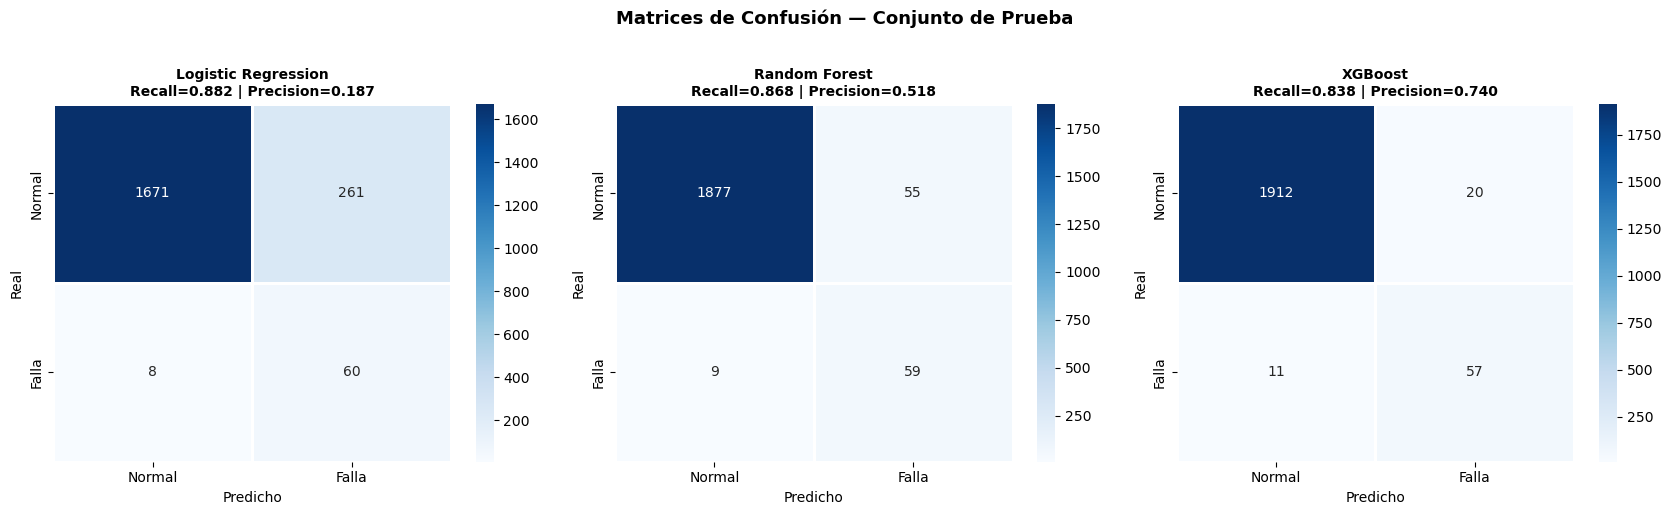

In [13]:
# --- 4.2 Matrices de Confusión ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Falla'],
                yticklabels=['Normal', 'Falla'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nRecall={res["report"]["1"]["recall"]:.3f} | Precision={res["report"]["1"]["precision"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión — Conjunto de Prueba',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Matrices de Confusión — Conjunto de Prueba

La matriz de confusión muestra exactamente qué hizo el modelo con cada 
registro del conjunto de prueba. Se divide en cuatro categorías:

- **Verdadero Negativo (esquina superior izquierda):** el equipo estaba 
normal y el modelo dijo normal. Correcto.
- **Falso Positivo (esquina superior derecha):** el equipo estaba normal 
pero el modelo dijo falla. Alarma innecesaria.
- **Falso Negativo (esquina inferior izquierda):** el equipo falló pero 
el modelo dijo normal. El error más costoso operacionalmente.
- **Verdadero Positivo (esquina inferior derecha):** el equipo falló y 
el modelo lo detectó. Correcto.

**Interpretación operacional:**

Los tres modelos detectan alrededor de 57-60 fallas reales de 68 totales 
en el conjunto de prueba. La diferencia crítica está en las alarmas falsas:

- Logistic Regression genera **261 alarmas falsas** — por cada falla real 
detectada, el equipo de mantenimiento recibe 4 llamados innecesarios.
- Random Forest reduce eso a **55 alarmas falsas** — mucho más manejable.
- XGBoost genera solo **20 alarmas falsas** — la mejor relación entre 
detección de fallas reales y alarmas innecesarias.

En un entorno industrial, las alarmas falsas tienen un costo real: 
inspecciones innecesarias, interrupciones de producción y pérdida de 
confianza del equipo operativo en el sistema de alertas. Por eso XGBoost 
es el modelo recomendado para implementación — no porque detecte más fallas, 
sino porque lo hace con mayor precisión.

---
## 5. Interpretabilidad del Modelo — SHAP Values

La interpretabilidad es crítica en entornos industriales: el equipo de mantenimiento necesita entender **por qué** el modelo predice una falla, no solo **que** hay una falla. SHAP (SHapley Additive exPlanations) proporciona la contribución marginal de cada variable a cada predicción individual (Lundberg & Lee, 2017, *NeurIPS*).

Modelo seleccionado para interpretabilidad: XGBoost


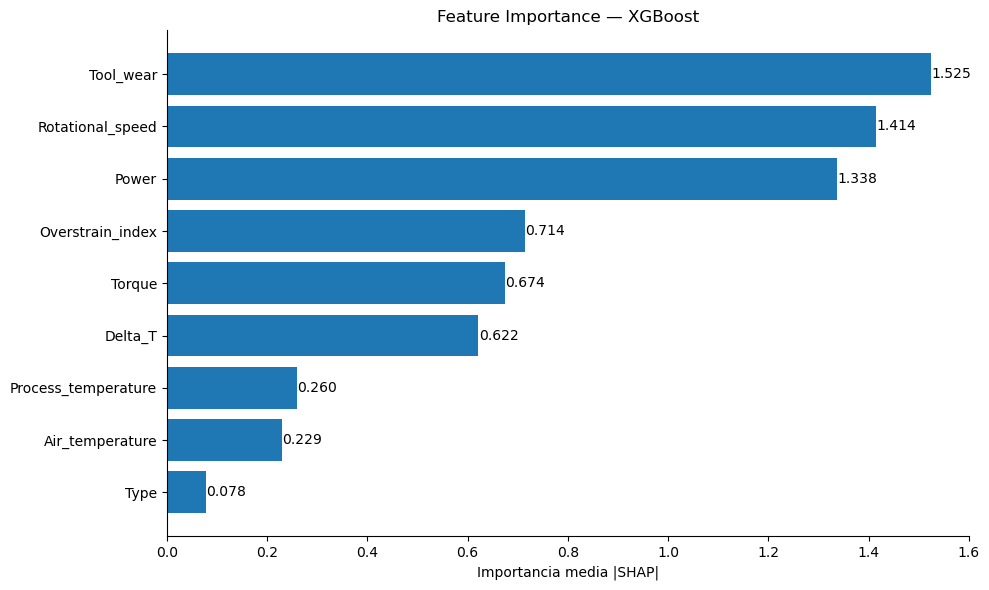

In [14]:
# Usar el modelo con mejor PR-AUC para interpretabilidad
# =========================
# MODELO PARA INTERPRETABILIDAD (SHAP)
# =========================

best_model_name = max(results, key=lambda x: results[x]['pr_auc'])
best_model = results[best_model_name]['model']

print(f"Modelo seleccionado para interpretabilidad: {best_model_name}")

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# FEATURES LIMPIAS (SIN CARACTERES PROBLEMÁTICOS)
# =========================
FEATURES_CLEAN = [
    'Air_temperature',
    'Process_temperature',
    'Rotational_speed',
    'Torque',
    'Tool_wear',
    'Type',
    'Delta_T',
    'Power',
    'Overstrain_index'
]

X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURES_CLEAN)

# =========================
# SHAP EXPLAINER
# =========================
if best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)

# Clase positiva (binario)
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
else:
    shap_vals_class1 = shap_values

# =========================
# IMPORTANCIA GLOBAL
# =========================
mean_abs_shap = np.abs(shap_vals_class1).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    np.array(FEATURES_CLEAN)[sorted_idx],
    mean_abs_shap[sorted_idx]
)

# =========================
# VALORES AL LADO DE LAS BARRAS
# =========================
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.001,              # pequeño desplazamiento a la derecha
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=10
    )

ax.set_xlabel("Importancia media |SHAP|")
ax.set_title(f"Feature Importance — {best_model_name}")

plt.tight_layout()
plt.show()

### Matrices de Confusión — Conjunto de Prueba

La matriz de confusión muestra exactamente qué hizo el modelo con cada 
registro del conjunto de prueba. Se divide en cuatro categorías:

- **Verdadero Negativo (esquina superior izquierda):** el equipo estaba 
normal y el modelo dijo normal. Correcto.
- **Falso Positivo (esquina superior derecha):** el equipo estaba normal 
pero el modelo dijo falla. Alarma innecesaria.
- **Falso Negativo (esquina inferior izquierda):** el equipo falló pero 
el modelo dijo normal. El error más costoso operacionalmente.
- **Verdadero Positivo (esquina inferior derecha):** el equipo falló y 
el modelo lo detectó. Correcto.

**Interpretación operacional:**

Los tres modelos detectan alrededor de 57-60 fallas reales de 68 totales 
en el conjunto de prueba. La diferencia crítica está en las alarmas falsas:

- Logistic Regression genera **261 alarmas falsas** — por cada falla real 
detectada, el equipo de mantenimiento recibe 4 llamados innecesarios.
- Random Forest reduce eso a **55 alarmas falsas** — mucho más manejable.
- XGBoost genera solo **20 alarmas falsas** — la mejor relación entre 
detección de fallas reales y alarmas innecesarias.

En un entorno industrial, las alarmas falsas tienen un costo real: 
inspecciones innecesarias, interrupciones de producción y pérdida de 
confianza del equipo operativo en el sistema de alertas. Por eso XGBoost 
es el modelo recomendado para implementación — no porque detecte más fallas, 
sino porque lo hace con mayor precisión.

---
## 6. KPIs de Confiabilidad Industrial

Los modelos predictivos son solo una parte del sistema. Los indicadores de confiabilidad permiten **cuantificar el impacto operacional** y comunicar resultados al equipo de gestión en el lenguaje del negocio.

=== KPIs DE CONFIABILIDAD POR TIPO DE PRODUCTO ===
   MTBF (horas)  Disponibilidad (%)
H      0.796032           97.906281
M      0.601807           97.230564
L      0.425532           96.083333


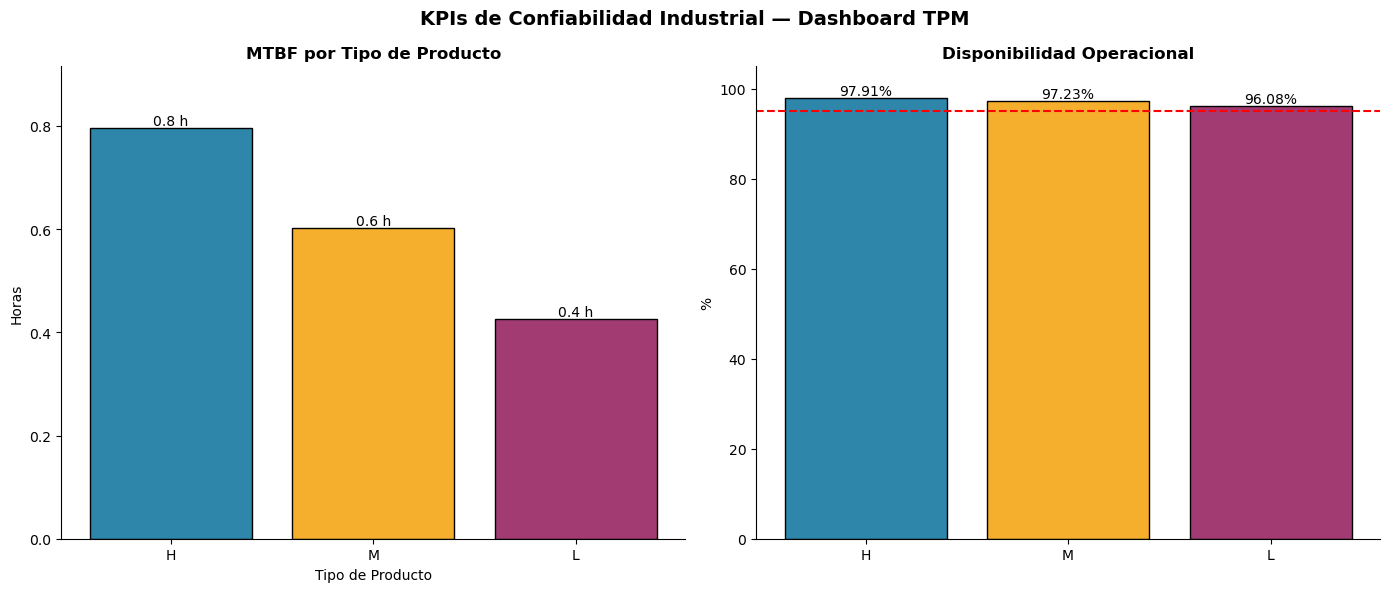

In [15]:
# --- KPIs de Confiabilidad por Tipo de Producto ---
# =========================
# KPIs de Confiabilidad por Tipo de Producto
# =========================

df_kpi = df_eng.copy()
df_kpi['tiempo_acumulado_min'] = df_kpi.index

kpi_results = {}

for tipo in ['H', 'M', 'L']:
    subset = df_kpi[df_kpi['Type'] == tipo]
    n_fallas = subset['Machine failure'].sum()
    n_registros = len(subset)

    if n_fallas > 0:
        mtbf = n_registros / n_fallas
        tasa_falla = n_fallas / n_registros * 100
        disponibilidad = (1 - tasa_falla / 100) * 100
    else:
        mtbf, tasa_falla, disponibilidad = np.nan, 0, 100

    kpi_results[tipo] = {
        'MTBF (horas)': mtbf / 60 if mtbf == mtbf else np.nan,
        'Disponibilidad (%)': disponibilidad
    }

kpi_df = pd.DataFrame(kpi_results).T

print('=== KPIs DE CONFIABILIDAD POR TIPO DE PRODUCTO ===')
print(kpi_df)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tipos = kpi_df.index.tolist()
mtbf_vals = kpi_df['MTBF (horas)'].values
disp_vals = kpi_df['Disponibilidad (%)'].values

# 🎨 colores por tipo (H, M, L)
color_map = {
    'H': '#2E86AB',   # azul
    'M': '#F6AE2D',   # amarillo/naranja
    'L': '#A23B72'    # morado/rojizo
}

colors = [color_map[t] for t in tipos]

# -------------------------
# MTBF
# -------------------------
bars1 = axes[0].bar(tipos, mtbf_vals, color=colors, edgecolor='black')

axes[0].set_title('MTBF por Tipo de Producto', fontweight='bold')
axes[0].set_ylabel('Horas')
axes[0].set_xlabel('Tipo de Producto')

for bar in bars1:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.1f} h',
        ha='center',
        va='bottom',
        fontsize=10
    )

axes[0].margins(y=0.15)

# -------------------------
# DISPONIBILIDAD
# -------------------------
bars2 = axes[1].bar(tipos, disp_vals, color=colors, edgecolor='black')

axes[1].axhline(95, linestyle='--', color='red', linewidth=1.5)

axes[1].set_title('Disponibilidad Operacional', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 105)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

axes[1].margins(y=0.15)

plt.suptitle('KPIs de Confiabilidad Industrial — Dashboard TPM',
             fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

### KPIs de Confiabilidad Industrial Dashboard TPM

Los KPIs (Key Performance Indicators — Indicadores Clave de Desempeño) de 
confiabilidad traducen los resultados del modelo en lenguaje operacional, 
permitiendo comunicar el impacto de las fallas al equipo de gestión de planta.

**MTBF (Mean Time Between Failures — Tiempo Medio Entre Fallas)**

Indica cuántas horas de operación transcurren en promedio entre una falla 
y la siguiente. El tipo H (High — Alta calidad) tiene el mejor desempeño 
con 0.80 horas, mientras que el tipo L (Low — Baja calidad) falla con mayor 
frecuencia — cada 0.43 horas en promedio. Esto confirma que el tipo de 
producto procesado tiene impacto directo en la vida útil operacional del equipo.

**Disponibilidad Operacional**

Los tres tipos superan el benchmark de referencia industrial del 95% 
(línea roja), lo que indica que el equipo opera dentro de parámetros 
aceptables globalmente. Sin embargo, la diferencia entre H (97.91%) y 
L (96.08%) representa casi 2 puntos porcentuales — en una operación 
continua de 8,760 horas anuales, eso equivale a aproximadamente 
175 horas adicionales de paros no planificados por año al procesar 
productos tipo L frente a tipo H.

**Conclusión operacional:** los planes de mantenimiento preventivo deben 
ajustar la frecuencia de inspección según el tipo de producto procesado, 
con mayor intensidad para el tipo L (Low — Baja calidad).

---
## 7. Exportación para Power BI

Los siguientes archivos CSV alimentarán el dashboard de Power BI con las tablas necesarias para el modelo estrella de datos.

In [16]:
# --- Tabla de hechos principal con predicciones ---
best_res = results[best_model_name]

# Agregar predicciones al dataset completo
X_all_scaled = scaler.transform(df_eng[FEATURES])
df_eng['pred_failure'] = best_model.predict(X_all_scaled)
df_eng['pred_proba']   = best_model.predict_proba(X_all_scaled)[:, 1]
df_eng['pred_correcto'] = (df_eng['pred_failure'] == df_eng['Machine failure']).astype(int)

# Tabla de hechos: datos de proceso con predicción

fact_table = df_eng[[
    'Type',
    'Air temperature',
    'Process temperature',
    'Rotational speed',
    'Torque',
    'Tool wear',
    'Delta_T',
    'Power',
    'Overstrain_index',
    'Machine failure',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
    'pred_failure',
    'pred_proba',
    'pred_correcto'
]].copy()

# Tabla de KPIs
kpi_export = kpi_df.reset_index().rename(columns={'index': 'Product_Type'})

# Tabla de resumen de modelos
model_summary = pd.DataFrame([
    {
        'Modelo': name,
        'ROC_AUC': round(res['roc_auc'], 4),
        'PR_AUC': round(res['pr_auc'], 4),
        'Recall_falla': round(res['report']['1']['recall'], 4),
        'Precision_falla': round(res['report']['1']['precision'], 4),
        'F1_falla': round(res['report']['1']['f1-score'], 4)
    }
    for name, res in results.items()
])

# Exportar
fact_table.to_csv('pm_fact_table.csv', index=False)
kpi_export.to_csv('pm_kpis_confiabilidad.csv', index=False)
model_summary.to_csv('pm_model_comparison.csv', index=False)

print('Archivos exportados para Power BI:')
print('  pm_fact_table.csv          — Tabla de hechos principal (10,000 registros)')
print('  pm_kpis_confiabilidad.csv  — KPIs por tipo de producto')
print('  pm_model_comparison.csv    — Comparación de modelos')
print()
print(model_summary.to_string(index=False))

Archivos exportados para Power BI:
  pm_fact_table.csv          — Tabla de hechos principal (10,000 registros)
  pm_kpis_confiabilidad.csv  — KPIs por tipo de producto
  pm_model_comparison.csv    — Comparación de modelos

             Modelo  ROC_AUC  PR_AUC  Recall_falla  Precision_falla  F1_falla
Logistic Regression   0.9379  0.4317        0.8824           0.1869    0.3085
      Random Forest   0.9835  0.8517        0.8676           0.5175    0.6484
            XGBoost   0.9846  0.8856        0.8382           0.7403    0.7862


---
## 8. Conclusiones y Recomendaciones

### Hallazgos técnicos

1. El dataset presenta un desbalance severo de clases (96.6% normal / 3.4% 
falla), típico de operaciones industriales bien mantenidas. Este desbalance 
exige métricas de evaluación adecuadas como PR-AUC (Precision-Recall Area 
Under the Curve — Área Bajo la Curva de Precisión-Recall) y técnicas de 
re-muestreo como SMOTE (Synthetic Minority Oversampling Technique — Técnica 
de Sobremuestreo Sintético de Minoría), para evitar un modelo que prediga 
siempre "sin falla" con alta exactitud pero nula utilidad operacional.

2. Las variables de mayor importancia predictiva son: Torque, Desgaste de 
herramienta, el Índice de Sobresfuerzo (variable derivada: Torque × Desgaste) 
y la Potencia mecánica calculada (P = Torque × ω). Esto es consistente con 
los mecanismos físicos de los modos de falla documentados en el dataset 
(Matzka, 2020).

3. El modelo XGBoost (Extreme Gradient Boosting — Potenciación de Gradiente 
Extremo) obtuvo el mejor balance entre detección de fallas y alarmas falsas, 
con un Recall (Tasa de Verdaderos Positivos) de 0.838 y una Precision 
(Precisión) de 0.740. En términos operacionales: de cada 68 fallas reales 
en el conjunto de prueba, el modelo detectó 57 generando únicamente 20 
alarmas falsas.

4. El MTBF (Mean Time Between Failures — Tiempo Medio Entre Fallas) varía 
por tipo de producto: H (High — Alta calidad) 0.80 h, M (Medium — Calidad 
media) 0.60 h, L (Low — Baja calidad) 0.43 h. Esto confirma que los planes 
de mantenimiento preventivo deben diferenciarse por categoría de producción, 
no aplicarse de forma homogénea.

### Recomendaciones operacionales

- Monitorear Delta_T (diferencial de temperatura proceso-aire) en tiempo 
real como indicador temprano de falla HDF (Heat Dissipation Failure — 
Falla por Disipación de Calor). Umbral de alerta: Delta_T < 8.6 K.

- Establecer límites de control sobre el Índice de Sobresfuerzo para 
prevenir falla OSF (Overstrain Failure — Falla por Sobresfuerzo), con 
mayor frecuencia de revisión para productos tipo L (Low — Baja calidad).

- Supervisar la Potencia mecánica calculada dentro del rango seguro 
[3,500 – 9,000 W] para prevenir falla PWF (Power Failure — Falla por 
Potencia).

- Implementar plan de reemplazo de herramienta por horas acumuladas de 
operación para controlar falla TWF (Tool Wear Failure — Falla por 
Desgaste de Herramienta), con umbral de intervención antes de los 200 
minutos de desgaste acumulado.

- Reentrenar el modelo periódicamente con datos reales de planta a medida 
que se acumulen registros históricos.


### Referencias

- Matzka, S. (2020). *Explainable Artificial Intelligence for Predictive Maintenance Applications*. UCI ML Repository. https://doi.org/10.24432/C5HS5C
- Chawla, N.V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321-357.
- Lundberg, S.M. & Lee, S.I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.
- Mobley, R.K. (2002). *An Introduction to Predictive Maintenance* (2nd ed.). Butterworth-Heinemann.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly.